# Chapter 102 — Sine and Cosine

> **Prerequisites:** ch101 (Trigonometry Intuition)
>
> **Outcomes:** Analyze properties of sin and cos: period, amplitude, phase; Derive key values analytically; Implement and visualize transformations of sin/cos


## Properties

**Both sin and cos:**
- Period: 2π (sin(x+2π) = sin(x))
- Range: [-1, 1]
- Continuous and differentiable everywhere

**sin(x):**
- sin(0) = 0; sin(π/2) = 1; sin(π) = 0; sin(3π/2) = -1
- sin is an **odd** function: sin(-x) = -sin(x)
- Derivative: d/dx sin(x) = cos(x)

**cos(x):**
- cos(0) = 1; cos(π/2) = 0; cos(π) = -1; cos(3π/2) = 0
- cos is an **even** function: cos(-x) = cos(x)
- Derivative: d/dx cos(x) = -sin(x)

**Relationship:** sin(x + π/2) = cos(x) — cosine is sine shifted by 90°.

**Taylor series (at x=0):**
sin(x) = x - x³/6 + x⁵/120 - ... = Σ (-1)ⁿ x^(2n+1) / (2n+1)!
cos(x) = 1 - x²/2 + x⁴/24 - ... = Σ (-1)ⁿ x^(2n) / (2n)!

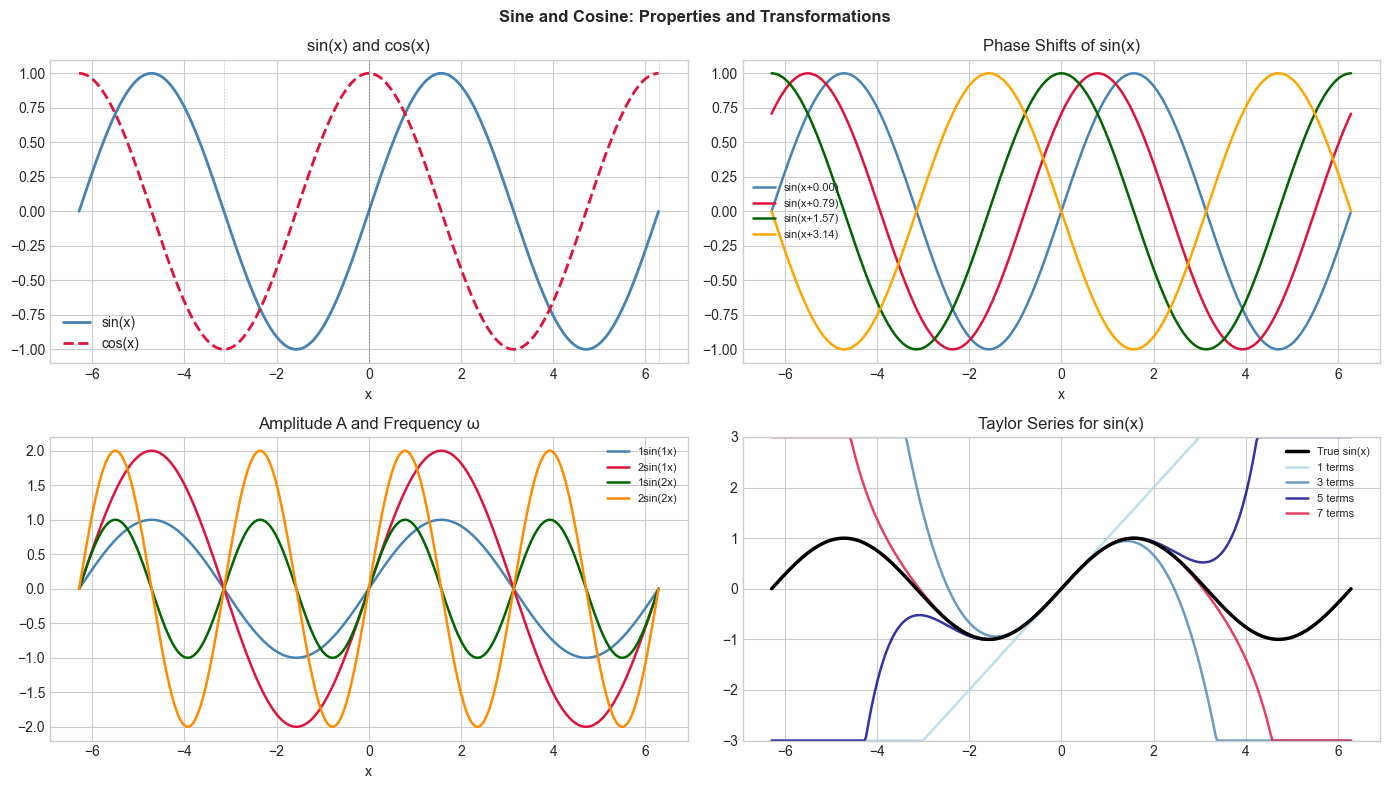

In [1]:
# --- Sine and cosine properties ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-2*np.pi, 2*np.pi, 600)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Basic sin and cos
axes[0,0].plot(x, np.sin(x), 'steelblue', lw=2, label='sin(x)')
axes[0,0].plot(x, np.cos(x), 'crimson', lw=2, linestyle='--', label='cos(x)')
for val, color in [(0,'black'),(np.pi,'gray'),(2*np.pi,'gray'),(-np.pi,'gray')]:
    axes[0,0].axvline(val, color=color, lw=0.4, linestyle=':')
axes[0,0].set_title('sin(x) and cos(x)'); axes[0,0].legend(); axes[0,0].set_xlabel('x')

# Phase shift
for phi, color in [(0,'steelblue'),(np.pi/4,'crimson'),(np.pi/2,'darkgreen'),(np.pi,'orange')]:
    axes[0,1].plot(x, np.sin(x + phi), color=color, lw=1.8, label=f'sin(x+{phi:.2f})')
axes[0,1].set_title('Phase Shifts of sin(x)'); axes[0,1].legend(fontsize=8); axes[0,1].set_xlabel('x')

# Amplitude and frequency
for A, omega, color in [(1,1,'steelblue'),(2,1,'crimson'),(1,2,'darkgreen'),(2,2,'darkorange')]:
    axes[1,0].plot(x, A*np.sin(omega*x), color=color, lw=1.8, label=f'{A}sin({omega}x)')
axes[1,0].set_title('Amplitude A and Frequency ω'); axes[1,0].legend(fontsize=8); axes[1,0].set_xlabel('x')

# Taylor series accuracy
x_zoom = np.linspace(-2*np.pi, 2*np.pi, 400)
axes[1,1].plot(x_zoom, np.sin(x_zoom), 'k-', lw=2.5, label='True sin(x)', zorder=5)
from math import factorial
for n, color in [(1,'lightblue'),(3,'steelblue'),(5,'darkblue'),(7,'crimson')]:
    approx = sum((-1)**k * x_zoom**(2*k+1) / factorial(2*k+1) for k in range((n+1)//2))
    axes[1,1].plot(x_zoom, np.clip(approx,-3,3), color=color, lw=1.8, alpha=0.8, label=f'{n} terms')
axes[1,1].set_ylim(-3,3); axes[1,1].set_title('Taylor Series for sin(x)'); axes[1,1].legend(fontsize=8)

plt.suptitle('Sine and Cosine: Properties and Transformations', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- sin(x): odd, period 2π, starts at 0; cos(x): even, period 2π, starts at 1
- Amplitude, frequency, phase: A·sin(ωx + φ) — the general sinusoid (ch067)
- Both have Taylor series expansions used in approximation and computation

**Forward:** ch103 connects sin/cos to the complex exponential; ch104 uses them for wave analysis.